# Inclusive vs exclusive OR: from a truth table to why neural nets need depth
### one disagreeing row -> parity -> the linear-separability wall

The two ORs differ in **exactly one** row:

| a | b | OR (inclusive) | XOR (exclusive) |
|---|---|----------------|-----------------|
| 0 | 0 | 0 | 0 |
| 0 | 1 | 1 | 1 |
| 1 | 0 | 1 | 1 |
| 1 | 1 | **1** | **0** |

Inclusive OR = "at least one true"; exclusive OR = "an **odd** number true". So a
chain of XORs is a **parity check** -- the gate form of the even/odd split in
`dgs.even_odd`. That one flipped row has a huge consequence downstream: XOR is the
classic function a single-layer network **cannot learn**, because its two 1-rows
sit on the diagonal and no straight line separates them. This notebook walks
logic -> actual voltage -> the perceptron wall -> the hidden-layer fix, all from
`dgs/exclusive_or.py`. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import exclusive_or as xo
print("ready -- numpy", np.__version__)
for a, b, o, x in xo.or_xor_tables():
    print(f"  {a} {b} | OR={o} | XOR={x}")
print("only disagreement:", xo.or_xor_disagreement())

ready -- numpy 2.4.4
  0 0 | OR=0 | XOR=0
  0 1 | OR=1 | XOR=1
  1 0 | OR=1 | XOR=1
  1 1 | OR=1 | XOR=0
only disagreement: (1, 1)


## 1. Exclusive OR *is* odd parity

XOR-reduce a bit string and you get 1 iff it holds an **odd** number of 1s -- that
is popcount mod 2, the even/odd parity bit. So "exclusive OR" generalizes from a
2-input gate to an n-input parity detector; it is the Boolean face of the parity
operator whose $\pm1$ eigenspaces are the even and odd functions.

In [2]:
tests = [[1,0,1,1,0], [1,1], [1,1,1], [0,0,0,0]]
for t in tests:
    print(f"XOR-reduce {t} = {xo.xor_reduce(t)}   (# of 1s = {sum(t)}, {'odd' if sum(t)%2 else 'even'})")
print("XOR == odd parity for all n up to 12?",
      all(xo.xor_is_odd_parity(n) for n in range(1, 13)))

XOR-reduce [1, 0, 1, 1, 0] = 1   (# of 1s = 3, odd)
XOR-reduce [1, 1] = 0   (# of 1s = 2, even)
XOR-reduce [1, 1, 1] = 1   (# of 1s = 3, odd)
XOR-reduce [0, 0, 0, 0] = 0   (# of 1s = 0, even)
XOR == odd parity for all n up to 12? True


## 2. Actual voltage -- these 0s and 1s live on a wire

A logic 0/1 is really $V_{SS}$/$V_{DD}$ on a physical net. Digital design only works
because those rails sit far enough apart to survive noise. A gate drives HIGH to at
least $V_{OH}$ and LOW to at most $V_{OL}$; the next gate reads HIGH above $V_{IH}$,
LOW below $V_{IL}$. The leftover slack is the **noise margin**
$$NM_H=V_{OH}-V_{IH},\qquad NM_L=V_{IL}-V_{OL}$$
-- the volts of garbage a stage tolerates before a 1 is misread as a 0.

logic [0,1,1,0] on the wire -> [0.  1.8 1.8 0. ] V
noise margins: NM_H = 0.50 V, NM_L = 0.50 V


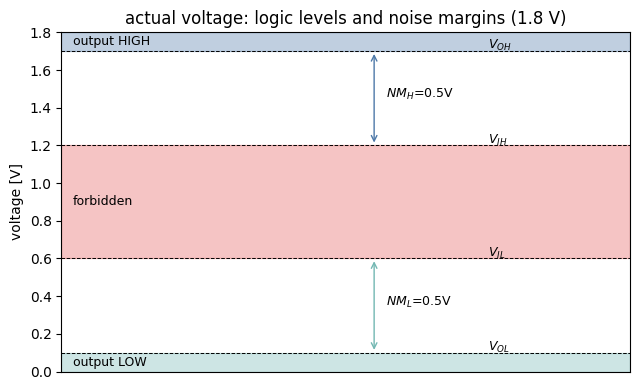

In [3]:
V_DD = 1.8
levels = dict(v_oh=1.7, v_ol=0.1, v_ih=1.2, v_il=0.6)
nmh, nml = xo.noise_margins(**levels)
print("logic [0,1,1,0] on the wire ->", xo.logic_to_voltage([0,1,1,0], v_dd=V_DD), "V")
print(f"noise margins: NM_H = {nmh:.2f} V, NM_L = {nml:.2f} V")

fig, ax = plt.subplots(figsize=(6.5, 4))
bands = [("output HIGH", levels['v_oh'], V_DD, "#4C78A8"),
         ("forbidden",   levels['v_il'], levels['v_ih'], "#E45756"),
         ("output LOW",   0.0, levels['v_ol'], "#72B7B2")]
for name, lo, hi, c in bands:
    ax.axhspan(lo, hi, color=c, alpha=0.35)
    ax.text(0.02, (lo+hi)/2, name, va="center", fontsize=9)
for lvl, name in [(levels['v_oh'],'$V_{OH}$'),(levels['v_ih'],'$V_{IH}$'),
                  (levels['v_il'],'$V_{IL}$'),(levels['v_ol'],'$V_{OL}$')]:
    ax.axhline(lvl, color="k", lw=0.7, ls="--"); ax.text(0.75, lvl+0.01, name, fontsize=9)
ax.annotate("", xy=(0.55, levels['v_oh']), xytext=(0.55, levels['v_ih']),
            arrowprops=dict(arrowstyle="<->", color="#4C78A8"))
ax.text(0.57, (levels['v_oh']+levels['v_ih'])/2, f"$NM_H$={nmh:.1f}V", fontsize=9)
ax.annotate("", xy=(0.55, levels['v_il']), xytext=(0.55, levels['v_ol']),
            arrowprops=dict(arrowstyle="<->", color="#72B7B2"))
ax.text(0.57, (levels['v_il']+levels['v_ol'])/2, f"$NM_L$={nml:.1f}V", fontsize=9)
ax.set(xlim=(0,1), ylim=(0,V_DD), ylabel="voltage [V]", xticks=[],
       title="actual voltage: logic levels and noise margins (1.8 V)")
plt.tight_layout(); plt.show()

## 3. The wall -- XOR is not linearly separable

Plot the four inputs in the plane and colour them by output. For **OR**, a single
straight line peels the one 0 away from the three 1s. For **XOR**, the two 1s sit on
*opposite corners* (the diagonal) with the two 0s on the other diagonal -- **no**
straight line can separate them. We decide this rigorously with linear programming
(`is_linearly_separable`): a separating line exists iff the LP is feasible.

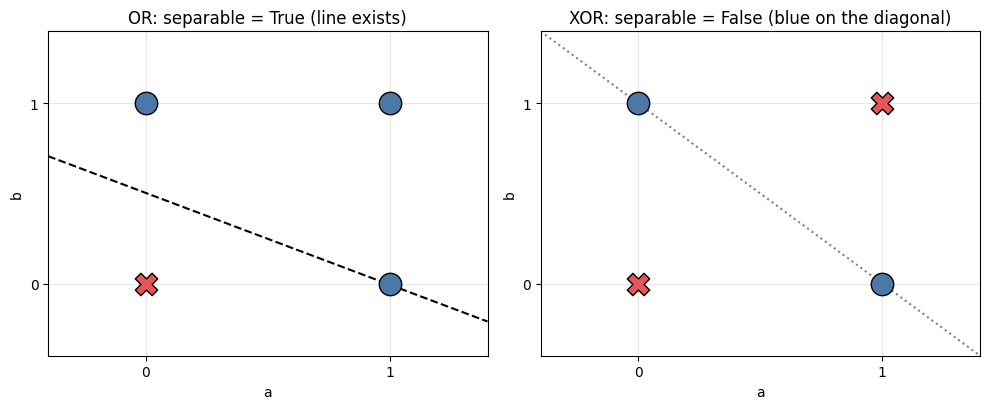

circles = output 1, X = output 0


In [4]:
def plot_points(ax, func, title):
    X, y = xo.boolean_dataset(func)
    for xi, yi in zip(X, y):
        ax.scatter(*xi, s=260, c=("#4C78A8" if yi>0 else "#E45756"),
                   marker=("o" if yi>0 else "X"), edgecolor="k", zorder=3)
    ax.set(xlim=(-0.4,1.4), ylim=(-0.4,1.4), xticks=[0,1], yticks=[0,1],
           xlabel="a", ylabel="b", title=title)
    ax.grid(alpha=0.3)
    return xo.is_linearly_separable(X, y)

fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
sep_or  = plot_points(ax[0], lambda a,b: a|b, "OR")
# draw the separating line the perceptron finds for OR
w, b, _, conv = xo.perceptron_train(*xo.boolean_dataset(lambda a,b: a|b), epochs=50)
xs = np.linspace(-0.4, 1.4, 50)
if abs(w[1]) > 1e-9:
    ax[0].plot(xs, -(w[0]*xs + b)/w[1], "k--", lw=1.5)
ax[0].set_title(f"OR: separable = {sep_or} (line exists)")
sep_xor = plot_points(ax[1], lambda a,b: a^b, "XOR")
ax[1].plot([-0.4,1.4],[1.4,-0.4], ":", color="gray")  # the frustrating diagonal
ax[1].set_title(f"XOR: separable = {sep_xor} (blue on the diagonal)")
plt.tight_layout(); plt.show()
print("circles = output 1, X = output 0")

## 4. A single perceptron proves it -- error that never reaches zero

The perceptron learning rule is guaranteed (convergence theorem) to reach **zero**
errors *iff* the data is linearly separable. Run it on OR and it converges in a
few epochs; run it on XOR and the error bounces forever, never hitting zero -- the
wall, made of nothing but that one flipped truth-table row.

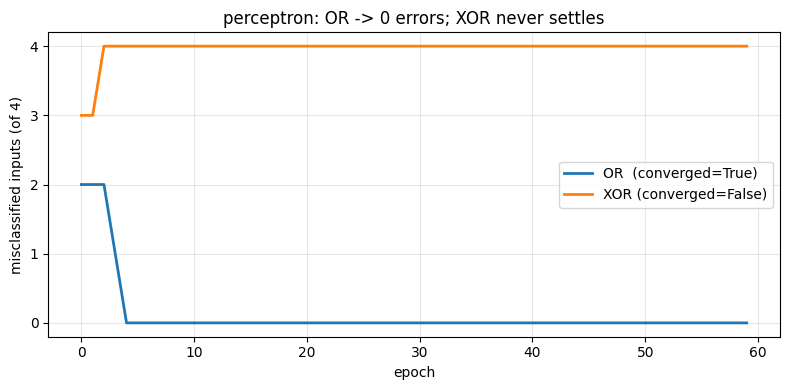

OR  final errors: 0   XOR final errors: 4


In [5]:
_, _, err_or,  conv_or  = xo.perceptron_train(*xo.boolean_dataset(lambda a,b: a|b),  epochs=60, seed=0)
_, _, err_xor, conv_xor = xo.perceptron_train(*xo.boolean_dataset(lambda a,b: a^b), epochs=60, seed=0)
plt.figure(figsize=(8, 4))
plt.plot(err_or,  lw=2, label=f"OR  (converged={conv_or})")
plt.plot(err_xor, lw=2, label=f"XOR (converged={conv_xor})")
plt.xlabel("epoch"); plt.ylabel("misclassified inputs (of 4)")
plt.title("perceptron: OR -> 0 errors; XOR never settles")
plt.legend(); plt.grid(alpha=0.3); plt.yticks(range(5)); plt.tight_layout(); plt.show()
print(f"OR  final errors: {err_or[-1]}   XOR final errors: {err_xor[-1]}")

## 5. The fix is depth -- a hidden layer folds the plane

Add one hidden layer, $2\to H\to 1$: each hidden unit draws its own line, and the
output combines them so XOR's diagonal becomes separable *in hidden space*. We train
a tiny NumPy net by backprop (the same math PyTorch would run) and plot the learned
**decision boundary** -- a bent region that captures the two diagonal 1s at once.
The loss falls to ~$10^{-4}$ and all four outputs are correct.

outputs: [0.007 0.989 0.991 0.012]  target: [0 1 1 0]  accuracy: 100%


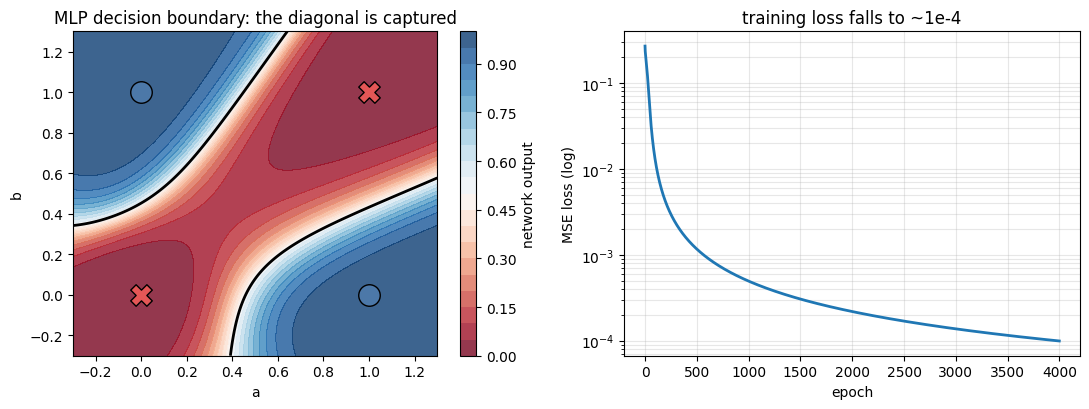

In [6]:
res = xo.mlp_xor_train(hidden=8, epochs=4000, lr=0.5, seed=0)
print("outputs:", np.round(res['pred'], 3), " target:", res['target'],
      " accuracy:", f"{res['accuracy']:.0%}")

# reconstruct the trained net to draw its decision surface
rng = np.random.default_rng(0)
W1 = rng.normal(0,1,(2,8)); b1=np.zeros(8); W2=rng.normal(0,1,(8,1)); b2=np.zeros(1)
X = np.array([[0,0],[0,1],[1,0],[1,1]],float); Y=np.array([[0.],[1.],[1.],[0.]])
sig = lambda z: 1/(1+np.exp(-z))
for _ in range(4000):
    h=np.tanh(X@W1+b1); o=sig(h@W2+b2)
    do=(o-Y)*o*(1-o); dh=(do@W2.T)*(1-h**2)
    W2-=0.5*h.T@do; b2-=0.5*do.sum(0); W1-=0.5*X.T@dh; b1-=0.5*dh.sum(0)
gx, gy = np.meshgrid(np.linspace(-0.3,1.3,200), np.linspace(-0.3,1.3,200))
grid = np.c_[gx.ravel(), gy.ravel()]
surf = sig(np.tanh(grid@W1+b1)@W2+b2).reshape(gx.shape)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
cf = ax[0].contourf(gx, gy, surf, levels=20, cmap="RdBu", alpha=0.8)
ax[0].contour(gx, gy, surf, levels=[0.5], colors="k", linewidths=2)
for xi, yi in zip(X, Y.ravel()):
    ax[0].scatter(*xi, s=240, c=("#4C78A8" if yi>0.5 else "#E45756"),
                  marker=("o" if yi>0.5 else "X"), edgecolor="k", zorder=3)
ax[0].set(xlabel="a", ylabel="b", title="MLP decision boundary: the diagonal is captured")
plt.colorbar(cf, ax=ax[0], label="network output")
ax[1].semilogy(res["losses"], lw=2)
ax[1].set(xlabel="epoch", ylabel="MSE loss (log)", title="training loss falls to ~1e-4")
ax[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## What we wired

* Inclusive vs exclusive OR differ in **one row** -- and that row makes XOR into
  **odd parity**, the gate form of `dgs.even_odd`.
* Those bits are **actual voltages**; noise margins $V_{OH}-V_{IH}$ and
  $V_{IL}-V_{OL}$ are the volts of slack that keep 1s and 0s apart.
* XOR is **not linearly separable** (proved by LP), so a single perceptron's error
  **never reaches zero** -- while OR converges immediately.
* A **hidden layer** folds the plane and clears the wall: the $2\to8\to1$ MLP learns
  XOR exactly. This is *the* reason neural networks need depth -- and it is the same
  even/odd structure surfacing as a learnability boundary, straight on the
  Griffiths -> ML axis.